In [44]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.loading import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


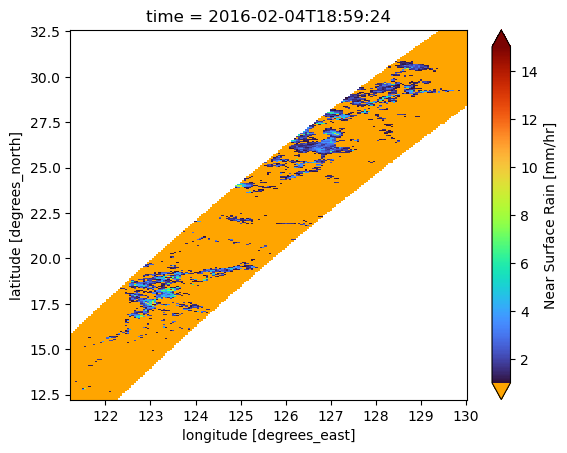

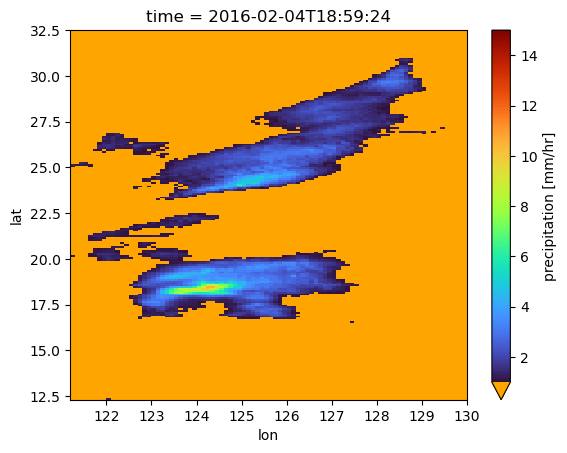

In [ ]:
cmap = plt.cm.turbo.copy()
norm = colors.Normalize(vmin=1, vmax=15)
cmap.set_under('orange')
# Plot features are observed by GPM:
gpm_swath_ds = xr.open_dataset(
   "/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/data/example_data/GPM2Ku7_uw4_20160204.185924_to_20160204.190633_011002_SAS.nc"
)
gpm_swath_ds['near_surf_rain'].squeeze().plot(
    cmap=cmap,
    norm=norm
)
plt.show()

# plot region as seen in IMERG:
imerg_data = load_example_imerg_file()
box_slice = {
    'lon': slice(gpm_swath_ds.lon.min(), gpm_swath_ds.lon.max()),
    'lat': slice(gpm_swath_ds.lat.min(), gpm_swath_ds.lat.max()),
}
imerg_box = imerg_data.sel(box_slice).interp(time=gpm_swath_ds.time)
imerg_box.plot(
    x='lon',
    cmap=cmap,
    norm=norm
)
plt.show()

# Plot just IMERG over swath:
swath_mask = ~(np.isnan(gpm_swath_ds['near_surf_rain']))
imerg_swath = imerg_box.where(swath_mask)
imerg_swath.plot()


In [56]:
R_EARTH_KM = 6371.0
GPM_RES_DEG = 0.05  # adjust if your GPM grid isn't 0.05 deg

def cell_bounds(centers):
    """Cell edges from 1-D ascending centers of a (near-)regular grid."""
    centers = np.asarray(centers, float)
    d = np.diff(centers)
    edges = np.empty(centers.size + 1)
    edges[1:-1] = centers[:-1] + d / 2
    edges[0] = centers[0] - d[0] / 2
    edges[-1] = centers[-1] + d[-1] / 2
    return edges

def cell_area_km2(dlat_deg, dlon_deg, lat_deg):
    """Approx. area of a lat/lon cell (km^2), latitude-dependent via cos(lat)."""
    dlat = np.deg2rad(dlat_deg)
    dlon = np.deg2rad(dlon_deg)
    return R_EARTH_KM**2 * dlat * dlon * np.cos(np.deg2rad(lat_deg))

def flat_valid_gpm_points(gpm_ds, var="near_surf_rain"):
    """Return 1-D lat, lon, rate for every valid (non-NaN) swath footprint."""
    rain = gpm_ds[var].squeeze()
    lat = gpm_ds["lat"].broadcast_like(rain)   # works for 1-D or 2-D coords
    lon = gpm_ds["lon"].broadcast_like(rain)
    r, la, lo = rain.values.ravel(), lat.values.ravel(), lon.values.ravel()
    good = np.isfinite(r)
    return la[good], lo[good], r[good]

def swath_footprint_on_grid(imerg_box, gpm_lat, gpm_lon):
    """Boolean DataArray on the IMERG grid: True where the swath was observed."""
    im = imerg_box.sortby("lat").sortby("lon")
    lat_c, lon_c = im["lat"].values, im["lon"].values
    lat_e, lon_e = cell_bounds(lat_c), cell_bounds(lon_c)

    iy = np.searchsorted(lat_e, gpm_lat) - 1
    ix = np.searchsorted(lon_e, gpm_lon) - 1
    inside = (iy >= 0) & (iy < lat_c.size) & (ix >= 0) & (ix < lon_c.size)

    covered = np.zeros((lat_c.size, lon_c.size), bool)
    covered[iy[inside], ix[inside]] = True
    return im, xr.DataArray(covered, dims=("lat", "lon"),
                            coords={"lat": im["lat"], "lon": im["lon"]})

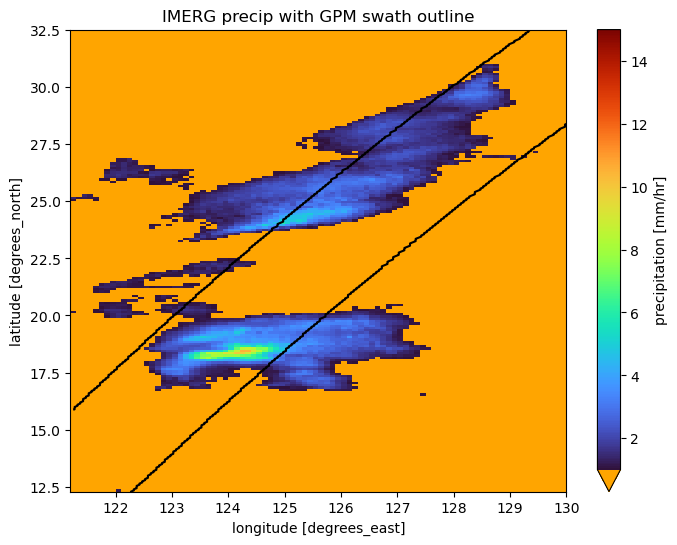

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))

# IMERG background
imerg_box.plot.pcolormesh(x="lon", y="lat", ax=ax, cmap=cmap, norm=norm)

# Swath outline: contour the valid-data mask on GPM's own grid
rain = gpm_swath_ds["near_surf_rain"].squeeze()
rain.notnull().astype(float).plot.contour(
    x="lon", y="lat", ax=ax,
    levels=[0.5], colors="black", linewidths=1.5, add_colorbar=False,
)

ax.set_title("IMERG precip with GPM swath outline")
plt.show()

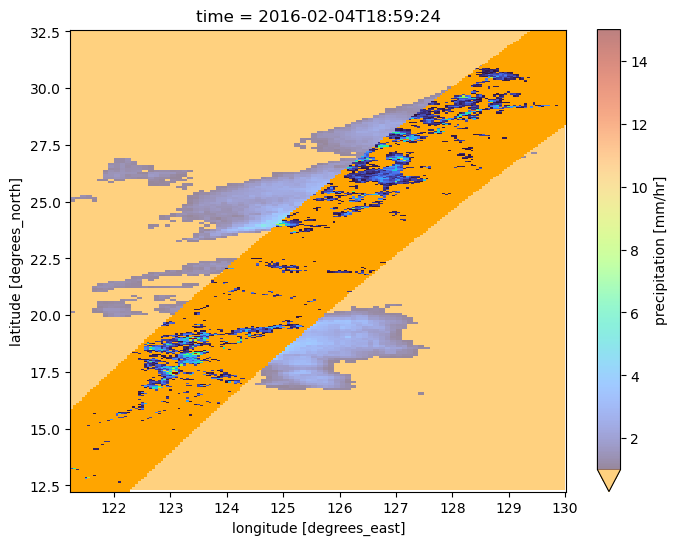

In [58]:
fig, ax = plt.subplots(figsize=(8, 6))
imerg_box.plot.pcolormesh(x="lon", y="lat", ax=ax, cmap=cmap, norm=norm, alpha=0.5)
gpm_swath_ds["near_surf_rain"].squeeze().plot.pcolormesh(
    x="lon", y="lat", ax=ax, cmap=cmap, norm=norm, add_colorbar=False)
plt.show()

In [59]:
# IMERG side
LON, LAT = np.meshgrid(imerg_box["lon"].values, imerg_box["lat"].values)
dlat_im = abs(np.diff(imerg_box["lat"].values).mean())
dlon_im = abs(np.diff(imerg_box["lon"].values).mean())
im_area = cell_area_km2(dlat_im, dlon_im, LAT)
im_rate = imerg_swath.values
m = np.isfinite(im_rate)
im_mean_rate = np.sum(im_rate[m] * im_area[m]) / im_area[m].sum()   # mm/hr
im_volflux   = np.sum(im_rate[m] * im_area[m]) * 1e3                # m^3/hr of water

# GPM side
gpm_area = cell_area_km2(GPM_RES_DEG, GPM_RES_DEG, gpm_lat)
gpm_mean_rate = np.sum(gpm_rate * gpm_area) / gpm_area.sum()        # mm/hr
gpm_volflux   = np.sum(gpm_rate * gpm_area) * 1e3                   # m^3/hr

print(f"IMERG: mean {im_mean_rate:.3f} mm/hr | flux {im_volflux:.3e} m^3/hr "
      f"over {im_area[m].sum():.0f} km^2")
print(f"GPM  : mean {gpm_mean_rate:.3f} mm/hr | flux {gpm_volflux:.3e} m^3/hr "
      f"over {gpm_area.sum():.0f} km^2")

IMERG: mean 1.029 mm/hr | flux 5.796e+08 m^3/hr over 563131 km^2
GPM  : mean 0.419 mm/hr | flux 2.309e+08 m^3/hr over 551164 km^2
